In [56]:
!pip install scikit-image -q

# BASELINE 1 HOG + SVM

---



# 1. Import Library

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [58]:
import random
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Load Dataset

In [59]:
train_df = pd.read_csv("train.csv")
print("Total missing value:", train_df.isnull().sum().sum())
print("Shape:", train_df.shape)

train_df.head()

Total missing value: 0
Shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Cek ukuran dataset:

In [60]:
print("Train shape:", train_df.shape)

Train shape: (42000, 785)


# 3. Exploratory Data Analysis

In [61]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


Cek missing value:

In [62]:
train_df.isnull().sum().sum()

np.int64(0)

Cek distribusi label:

In [63]:
train_df["label"].value_counts().sort_index()

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


Visualisasi distribusi label:

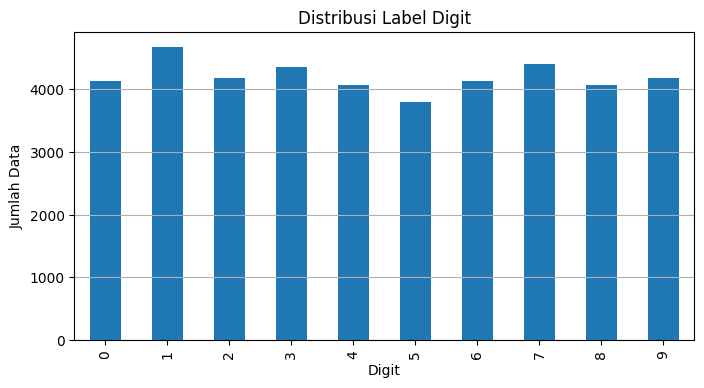

In [64]:
plt.figure(figsize=(8, 4))
train_df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Label Digit")
plt.xlabel("Digit")
plt.ylabel("Jumlah Data")
plt.grid(axis="y")
plt.show()

Visualisasi contoh gambar:

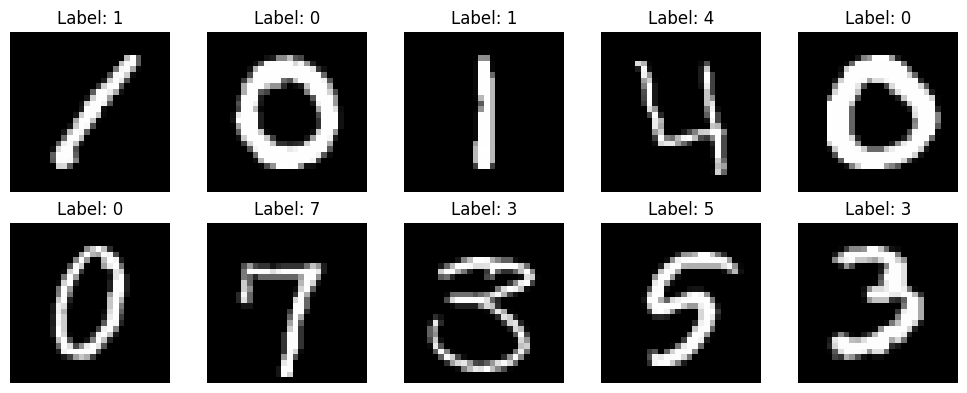

In [65]:
X_preview = train_df.drop("label", axis=1).values
y_preview = train_df["label"].values

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_preview[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_preview[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Data Preprocessing

Pisahkan fitur dan label:

In [66]:
# Pisahkan fitur dan label
X = train_df.drop("label", axis=1)
y = train_df["label"]

# Isi missing value jika ada
X = X.fillna(0)

# Ubah ke numpy array
X = X.to_numpy()
y = y.to_numpy()

# Pastikan tipe numerik
X = X.astype("float32")

# Normalisasi pixel
X = X / 255.0

print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaN pada X:", np.isnan(X).sum())

X shape: (42000, 784)
y shape: (42000,)
NaN pada X: 0


Normalisasi pixel:

In [67]:
X = X / 255.0

# 5. Train-Validation Split

In [68]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (33600, 784)
X_val: (8400, 784)
y_train: (33600,)
y_val: (8400,)


# 6. Feature Engineering: Ekstraksi HOG

In [69]:
def extract_hog_features(images):
    hog_features = []

    for img in images:
        img = np.nan_to_num(img, nan=0.0)

        # Pastikan setiap gambar punya 784 pixel
        if img.size != 784:
            print("Ukuran gambar bermasalah:", img.size)
            continue

        img_2d = img.reshape(28, 28)

        features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        features = np.nan_to_num(features, nan=0.0)
        hog_features.append(features)

    return np.array(hog_features)

In [70]:
start_hog = time.time()

X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)

hog_extraction_time = time.time() - start_hog

print("X_train_hog shape:", X_train_hog.shape)
print("X_val_hog shape:", X_val_hog.shape)
print("HOG Extraction Time:", hog_extraction_time)

print("NaN pada X_train_hog:", np.isnan(X_train_hog).sum())
print("NaN pada X_val_hog:", np.isnan(X_val_hog).sum())

X_train_hog shape: (33600, 1296)
X_val_hog shape: (8400, 1296)
HOG Extraction Time: 43.85436987876892
NaN pada X_train_hog: 0
NaN pada X_val_hog: 0


# 7. Modeling: Training SVM

In [71]:
svm_model = LinearSVC(
    random_state=SEED,
    max_iter=5000
)

start_train = time.time()

svm_model.fit(X_train_hog, y_train)

svm_train_time = time.time() - start_train

print("SVM Training Time:", svm_train_time)

SVM Training Time: 12.076166868209839


# 8. Evaluation

In [72]:
start_infer = time.time()

y_pred_hog_svm = svm_model.predict(X_val_hog)

svm_inference_time = time.time() - start_infer

In [73]:
acc_hog_svm = accuracy_score(y_val, y_pred_hog_svm)

print("Accuracy HOG + SVM:", acc_hog_svm)
print("SVM Inference Time:", svm_inference_time)

Accuracy HOG + SVM: 0.9769047619047619
SVM Inference Time: 0.037093400955200195


In [74]:
print(classification_report(y_val, y_pred_hog_svm))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       827
           1       0.99      0.99      0.99       937
           2       0.98      0.98      0.98       835
           3       0.97      0.97      0.97       870
           4       0.98      0.97      0.98       814
           5       0.98      0.97      0.97       759
           6       0.98      0.98      0.98       827
           7       0.97      0.97      0.97       880
           8       0.98      0.96      0.97       813
           9       0.96      0.97      0.96       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



# 9. Confusion Matrix

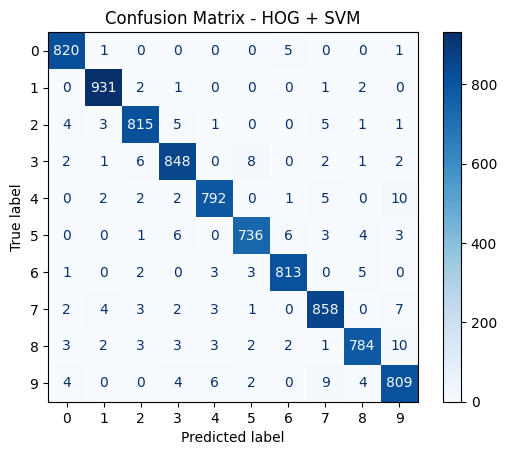

In [75]:
cm_hog_svm = confusion_matrix(y_val, y_pred_hog_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hog_svm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - HOG + SVM")
plt.show()

# 10. Misclassification Analysis

In [76]:
wrong_idx = np.where(y_val != y_pred_hog_svm)[0]

print("Jumlah salah klasifikasi:", len(wrong_idx))

Jumlah salah klasifikasi: 194


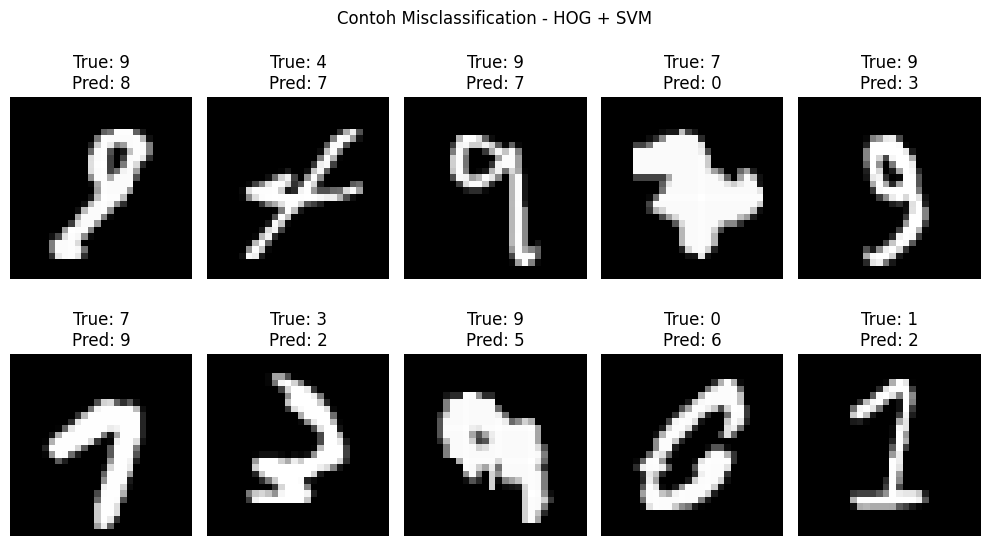

In [77]:
plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_val[idx]}\nPred: {y_pred_hog_svm[idx]}")
    plt.axis("off")

plt.suptitle("Contoh Misclassification - HOG + SVM")
plt.tight_layout()
plt.show()

Ringkasan pola salah prediksi:

In [78]:
mis_hog_svm = pd.DataFrame({
    "True Label": y_val[wrong_idx],
    "Predicted Label": y_pred_hog_svm[wrong_idx]
})

mis_hog_svm.value_counts().reset_index(name="Count").head(10)

,True Label,Predicted Label,Count
0,4,9,10
1,8,9,10
2,9,7,9
3,3,5,8
4,7,9,7
5,5,3,6
6,5,6,6
7,9,4,6
8,3,2,6
9,2,7,5


# 11. Catat Training Time dan Inference Time

In [79]:
print("HOG Extraction Time:", hog_extraction_time)
print("SVM Training Time:", svm_train_time)
print("SVM Inference Time:", svm_inference_time)

HOG Extraction Time: 43.85436987876892
SVM Training Time: 12.076166868209839
SVM Inference Time: 0.037093400955200195


# 12. Simpan Hasil ke Tabel Perbandingan

In [80]:
baseline1_result = pd.DataFrame({
    "Model": ["HOG + SVM"],
    "Accuracy": [acc_hog_svm],
    "HOG Extraction Time": [hog_extraction_time],
    "Training Time": [svm_train_time],
    "Inference Time": [svm_inference_time]
})

baseline1_result

,Model,Accuracy,HOG Extraction Time,Training Time,Inference Time
0,HOG + SVM,0.976905,43.85437,12.076167,0.037093


# **Baseline 2 — PCA + KNN**

---



# 1. Import Library Tambahan

In [81]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 2. Membuat Pipeline PCA + KNN

In [82]:
pca_knn_model = Pipeline([
    ("pca", PCA(n_components=100, random_state=SEED)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# 3. Training Model PCA + KNN

In [83]:
start_train = time.time()

pca_knn_model.fit(X_train, y_train)

pca_knn_train_time = time.time() - start_train

print("PCA + KNN Training Time:", pca_knn_train_time)

PCA + KNN Training Time: 0.5045478343963623


# 4. Prediksi Data Validation

In [84]:
start_infer = time.time()

y_pred_pca_knn = pca_knn_model.predict(X_val)

pca_knn_inference_time = time.time() - start_infer

print("PCA + KNN Inference Time:", pca_knn_inference_time)

PCA + KNN Inference Time: 2.1543691158294678


# 5. Evaluasi Accuracy

In [85]:
acc_pca_knn = accuracy_score(y_val, y_pred_pca_knn)

print("Accuracy PCA + KNN:", acc_pca_knn)

Accuracy PCA + KNN: 0.9701190476190477


# 6. Classification Report

In [86]:
print(classification_report(y_val, y_pred_pca_knn))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       827
           1       0.96      1.00      0.98       937
           2       0.99      0.97      0.98       835
           3       0.97      0.96      0.96       870
           4       0.98      0.97      0.97       814
           5       0.95      0.96      0.96       759
           6       0.98      0.99      0.98       827
           7       0.97      0.98      0.97       880
           8       0.99      0.92      0.96       813
           9       0.94      0.97      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



# 7. Confusion Matrix

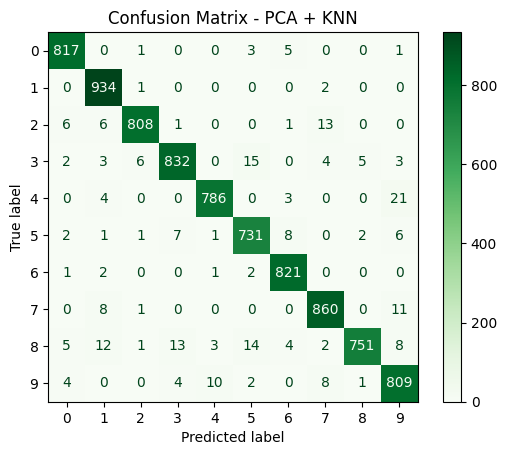

In [87]:
cm_pca_knn = confusion_matrix(y_val, y_pred_pca_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pca_knn,
    display_labels=np.arange(10)
)

disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix - PCA + KNN")
plt.show()

# 8. Misclassification Analysis

In [88]:
wrong_pca_knn = np.where(y_val != y_pred_pca_knn)[0]

print("Jumlah salah klasifikasi PCA + KNN:", len(wrong_pca_knn))

Jumlah salah klasifikasi PCA + KNN: 251


Tampilkan contoh gambar yang salah diklasifikasi:

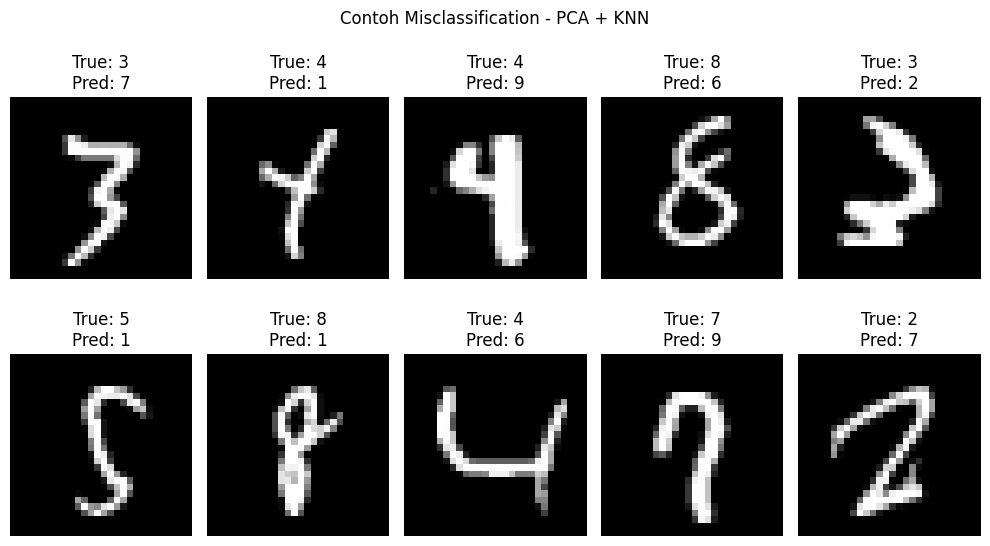

In [89]:
plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong_pca_knn[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_val[idx]}\nPred: {y_pred_pca_knn[idx]}")
    plt.axis("off")

plt.suptitle("Contoh Misclassification - PCA + KNN")
plt.tight_layout()
plt.show()

Ringkasan pola salah prediksi:

In [90]:
mis_pca_knn = pd.DataFrame({
    "True Label": y_val[wrong_pca_knn],
    "Predicted Label": y_pred_pca_knn[wrong_pca_knn]
})

mis_pca_knn.value_counts().reset_index(name="Count").head(10)

,True Label,Predicted Label,Count
0,4,9,21
1,3,5,15
2,8,5,14
3,2,7,13
4,8,3,13
5,8,1,12
6,7,9,11
7,9,4,10
8,7,1,8
9,5,6,8


# 9. Simpan Hasil Baseline 2

In [91]:
baseline2_result = pd.DataFrame({
    "Model": ["PCA + KNN"],
    "Accuracy": [acc_pca_knn],
    "Training Time": [pca_knn_train_time],
    "Inference Time": [pca_knn_inference_time],
    "Misclassification Count": [len(wrong_pca_knn)]
})

baseline2_result

,Model,Accuracy,Training Time,Inference Time,Misclassification Count
0,PCA + KNN,0.970119,0.504548,2.154369,251


# 10. Gabungkan Hasil Baseline 1 dan Baseline 2

In [92]:
baseline1_result_simple = pd.DataFrame({
    "Model": ["HOG + SVM"],
    "Accuracy": [acc_hog_svm],
    "Training Time": [svm_train_time],
    "Inference Time": [svm_inference_time],
    "Misclassification Count": [len(wrong_idx)]
})

Lalu gabungkan

In [93]:
baseline_comparison = pd.concat(
    [baseline1_result_simple, baseline2_result],
    ignore_index=True
)

baseline_comparison

,Model,Accuracy,Training Time,Inference Time,Misclassification Count
0,HOG + SVM,0.976905,12.076167,0.037093,194
1,PCA + KNN,0.970119,0.504548,2.154369,251


# **Deep Learning — CNN**

---



# 1. Import Library Tambahan

In [94]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 2. Reshape Data untuk CNN
Data awal masih berbentuk:

(jumlah_data, 784)

CNN butuh bentuk:

(jumlah_data, 28, 28, 1)

In [95]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)

print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn:", X_val_cnn.shape)

X_train_cnn: (33600, 28, 28, 1)
X_val_cnn: (8400, 28, 28, 1)


# 3. One-Hot Encoding Label

In [96]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)

print("y_train_cat:", y_train_cat.shape)
print("y_val_cat:", y_val_cat.shape)

y_train_cat: (33600, 10)
y_val_cat: (8400, 10)


# 4. Build Model CNN

In [97]:
cnn_model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Compile Model

In [98]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 6. Training CNN

In [99]:
start_train = time.time()

history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)

cnn_train_time = time.time() - start_train

print("CNN Training Time:", cnn_train_time)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.4561 - loss: 1.6196 - val_accuracy: 0.7982 - val_loss: 0.6631
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.8240 - loss: 0.5676 - val_accuracy: 0.8815 - val_loss: 0.3875
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.8721 - loss: 0.4110 - val_accuracy: 0.9031 - val_loss: 0.3067
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.8952 - loss: 0.3421 - val_accuracy: 0.9206 - val_loss: 0.2575
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.9087 - loss: 0.2962 - val_accuracy: 0.9298 - val_loss: 0.2233
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.9194 - loss: 0.2617 - val_accuracy: 0.9350 - val_loss: 0.2001
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9279 - loss: 0.2351 - val_accuracy: 0.9419 - val_loss: 0.1777
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9339 - loss: 0.2132 - 

# 7. Evaluasi CNN

In [100]:
start_infer = time.time()

y_pred_cnn_prob = cnn_model.predict(X_val_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)

cnn_inference_time = time.time() - start_infer

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [101]:
acc_cnn = accuracy_score(y_val, y_pred_cnn)

print("CNN Accuracy:", acc_cnn)
print("CNN Inference Time:", cnn_inference_time)

CNN Accuracy: 0.955952380952381
CNN Inference Time: 2.613056182861328


# 8. Classification Report

In [102]:
print(classification_report(y_val, y_pred_cnn))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       827
           1       0.98      0.98      0.98       937
           2       0.95      0.96      0.95       835
           3       0.95      0.92      0.94       870
           4       0.96      0.94      0.95       814
           5       0.95      0.95      0.95       759
           6       0.95      0.99      0.97       827
           7       0.96      0.95      0.96       880
           8       0.94      0.95      0.95       813
           9       0.92      0.94      0.93       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



# 9. Confusion Matrix

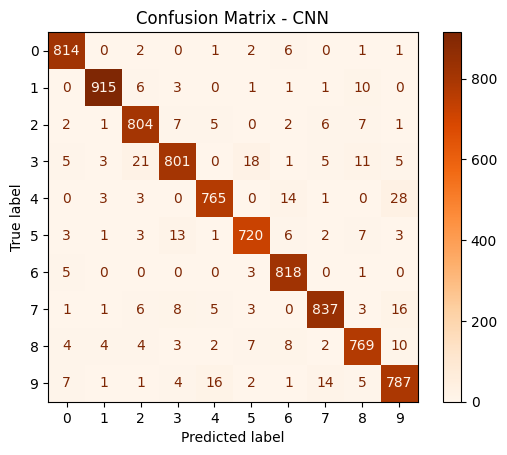

In [103]:
cm_cnn = confusion_matrix(y_val, y_pred_cnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=np.arange(10)
)

disp.plot(cmap="Oranges", values_format="d")
plt.title("Confusion Matrix - CNN")
plt.show()

# 10. Visualisasi Training History

Accuracy

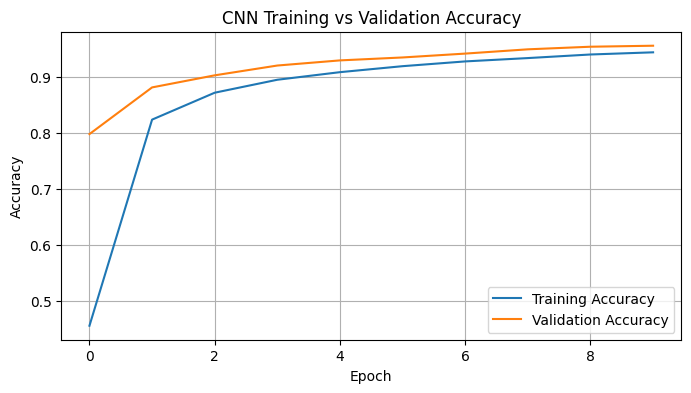

In [104]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

Loss

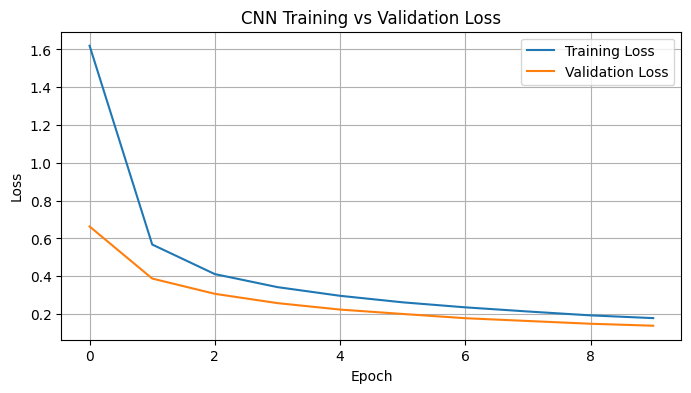

In [105]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# 11. Misclassification Analysis

In [106]:
wrong_cnn = np.where(y_val != y_pred_cnn)[0]

print("Jumlah salah klasifikasi CNN:", len(wrong_cnn))

Jumlah salah klasifikasi CNN: 370


Tampilkan contoh gambar yang salah diklasifikasi:

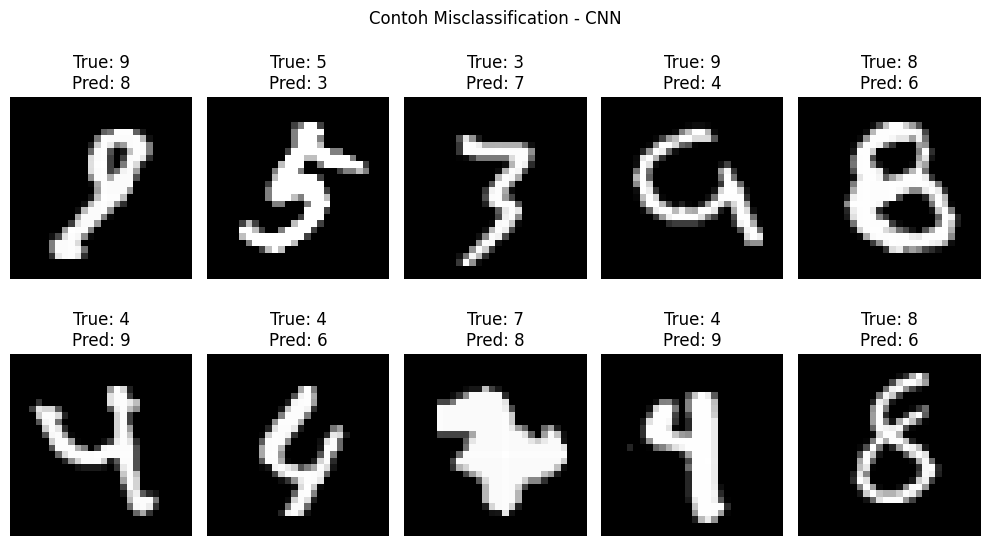

In [107]:
plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong_cnn[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_val[idx]}\nPred: {y_pred_cnn[idx]}")
    plt.axis("off")

plt.suptitle("Contoh Misclassification - CNN")
plt.tight_layout()
plt.show()

Ringkasan pola salah prediksi CNN:

In [108]:
mis_cnn = pd.DataFrame({
    "True Label": y_val[wrong_cnn],
    "Predicted Label": y_pred_cnn[wrong_cnn]
})

mis_cnn.value_counts().reset_index(name="Count").head(10)

,True Label,Predicted Label,Count
0,4,9,28
1,3,2,21
2,3,5,18
3,7,9,16
4,9,4,16
5,9,7,14
6,4,6,14
7,5,3,13
8,3,8,11
9,1,8,10


# 12. Simpan Hasil CNN

In [109]:
cnn_result = pd.DataFrame({
    "Model": ["CNN"],
    "Accuracy": [acc_cnn],
    "Training Time": [cnn_train_time],
    "Inference Time": [cnn_inference_time],
    "Misclassification Count": [len(wrong_cnn)]
})

cnn_result

,Model,Accuracy,Training Time,Inference Time,Misclassification Count
0,CNN,0.955952,180.089964,2.613056,370


# 13. Gabungkan Semua Hasil Model

gabungkan dengan hasil CNN:

In [110]:
final_comparison = pd.concat(
    [baseline_comparison, cnn_result],
    ignore_index=True
)

final_comparison

,Model,Accuracy,Training Time,Inference Time,Misclassification Count
0,HOG + SVM,0.976905,12.076167,0.037093,194
1,PCA + KNN,0.970119,0.504548,2.154369,251
2,CNN,0.955952,180.089964,2.613056,370


Catatan Reproducibility dan Fair Comparison

Eksperimen ini menggunakan random seed yang konsisten, yaitu 42. Seed diterapkan pada NumPy, Python random, TensorFlow, serta parameter random_state pada metode yang mendukung, seperti train_test_split, LinearSVC, dan PCA.

Pembagian data train dan validation dilakukan satu kali menggunakan train_test_split dengan random_state=42 dan stratify=y. Split data yang sama kemudian digunakan untuk seluruh model, yaitu HOG + SVM, PCA + KNN, dan CNN. Dengan demikian, perbandingan antar model dilakukan secara fair karena seluruh model dievaluasi pada validation set yang sama.

Tuning model dilakukan secara wajar dan sederhana. HOG + SVM menggunakan LinearSVC dengan max_iter=5000. PCA + KNN menggunakan PCA dengan 100 komponen utama dan KNN dengan k=5. CNN menggunakan arsitektur sederhana dengan dua convolution layer, dua max pooling layer, dense layer, dropout, optimizer Adam, batch size 128, dan 10 epoch. Tidak ada satu model yang dituning secara berlebihan dibandingkan model lainnya.

Urutkan berdasarkan akurasi:

In [111]:
final_comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Training Time,Inference Time,Misclassification Count
0,HOG + SVM,0.976905,12.076167,0.037093,194
1,PCA + KNN,0.970119,0.504548,2.154369,251
2,CNN,0.955952,180.089964,2.613056,370


# **Full Code Submit Prediction**

---



In [112]:
# Load test dataset
test_df = pd.read_csv("test.csv")

# Preprocessing test dataset
X_test = test_df.values
X_test = X_test / 255.0

# Reshape untuk CNN
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Prediksi menggunakan model CNN
test_pred_prob = cnn_model.predict(X_test_cnn)
test_pred = np.argmax(test_pred_prob, axis=1)

# Buat file submission
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_pred) + 1),
    "Label": test_pred
})

# Simpan ke CSV
submission.to_csv("submission.csv", index=False)

# Lihat hasil awal
submission.head()

875/875 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step


,ImageId,Label
0,1,2
1,2,0
2,3,8
3,4,9
4,5,3


In [113]:
submission["Label"].value_counts().sort_index()

,count
Label,
0,2938
1,3528
2,2886
3,2980
4,2918
5,2315
6,2772
7,3066
8,2286


In [114]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>